# Acoustic Co-Design Demo

This notebook is the central entry point for all co-design experiments.
Change the **Configuration** cell below and re-run to switch between:

- Materials (steel / spruce)
- Target frequency spectra
- Co-design modes (LQR actuators / string tensions / both)
- Grid resolution and scale

Everything downstream reads from that single cell.

In [1]:
# ======================================================================
# CONFIGURATION -- edit this cell, then Kernel > Restart & Run All
# ======================================================================

# --- Mode ---
MODE = 'both'          # 'lqr' | 'strings' | 'both'

# --- Material ---
MATERIAL = 'spruce'    # 'steel' | 'spruce'

# --- LQR target spectrum (Gaussian peaks, used when MODE is 'lqr' or 'both') ---
# Centers and widths in Hz. Widths control how narrow each target peak is.
# Narrow (15-30 Hz): tight frequency matching, harder for the controller.
# Broad  (50-80 Hz): forgiving, more typical of real instrument formants.
LQR_TARGET_CENTERS = [275.0, 440.0, 540.0]  # Hz
LQR_TARGET_WIDTHS  = [15.0,  20.0,  30.0]   # Hz

# --- String targets (used when MODE is 'strings' or 'both') ---
# These are the notes the strings should produce (fundamental frequencies).
# Examples:
#   Violin open strings: [196.0, 293.7, 440.0, 659.3]  (G3, D4, A4, E5)
#   Custom chord:        [275.0, 440.0, 540.0]          (C#4, A4, C#5)
STRING_TARGET_PITCHES = [196.0, 293.7, 440.0, 659.3]   # Hz  (C#4, A4, C#5)
STRING_TARGET_WIDTHS  = 40.0                     # Hz, Gaussian width per peak
STRING_N_HARMONICS    = 6                        # how many overtones to include

# --- Plate and optimizer settings ---
N_ACTUATORS    = 6      # number of piezo actuators (LQR mode only)
PASSIVE_STEPS  = 300
CODESIGN_STEPS = 400
SEED           = 18848

# --- Scale profile ---
# 'small'  -> CPU-friendly quick runs  (Nx=25, Ny=20, M=3, n_modes=10)
# 'medium' -> single GPU default       (Nx=50, Ny=40, M=5, n_modes=20)
# 'large'  -> GPU stress test          (Nx=80, Ny=60, M=7, n_modes=30)
SCALE = 'medium'
# ======================================================================

In [2]:
# If running on Colab, uncomment:
# !pip install -q jax optax matplotlib
# !git clone https://github.com/chrisjinyu/acoustic-codesign.git
# %cd acoustic-codesign

import importlib
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
import json

jax.config.update('jax_enable_x64', True)

# --- Resolve scale profile ---
_SCALES = {
    'small':  dict(Nx=25, Ny=20, M=3, n_modes=10),
    'medium': dict(Nx=50, Ny=40, M=5, n_modes=20),
    'large':  dict(Nx=80, Ny=60, M=7, n_modes=30),
}
assert SCALE in _SCALES, f"SCALE must be one of {list(_SCALES)}"
scale_kwargs = _SCALES[SCALE]

# --- Import core and apply config BEFORE downstream modules ---
import codesign_core as core
core.reconfigure(
    material=MATERIAL,
    n_actuators=N_ACTUATORS,
    **scale_kwargs,
)

# Reload downstream modules so they pick up the updated cfg and grid globals
import codesign
import codesign_strings
importlib.reload(codesign)
importlib.reload(codesign_strings)

# Apply string config overrides
import dataclasses
codesign_strings.scfg = dataclasses.replace(
    codesign_strings.scfg,
    target_pitches_hz=tuple(STRING_TARGET_PITCHES),
    target_width_hz=STRING_TARGET_WIDTHS,
    n_harmonics=STRING_N_HARMONICS,
)

import plots
importlib.reload(plots)

from codesign_core import cfg

print()
print(f'JAX backend : {jax.default_backend()}')
print(f'Plate       : {cfg.Lx*1e3:.0f} x {cfg.Ly*1e3:.0f} mm, grid {cfg.Nx} x {cfg.Ny}')
print(f'Material    : {cfg.material}  (E={cfg.E:.2e} Pa, rho={cfg.rho:.0f} kg/m^3)')
print(f'Mode        : {MODE}')
print(f'LQR target  : {LQR_TARGET_CENTERS} Hz  (widths {LQR_TARGET_WIDTHS} Hz)')
if MODE in ('strings', 'both'):
    print(f'String notes: {STRING_TARGET_PITCHES} Hz')

E0419 18:50:34.431701   15175 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0419 18:50:34.441733   15102 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


Reconfigured: material=spruce, E=1.00e+10 Pa, rho=450 kg/m^3, n_actuators=6, grid=50x40, M=5

JAX backend : gpu
Plate       : 300 x 200 mm, grid 50 x 40
Material    : spruce  (E=1.00e+10 Pa, rho=450 kg/m^3)
Mode        : both
LQR target  : [275.0, 440.0, 540.0] Hz  (widths [15.0, 20.0, 30.0] Hz)
String notes: [196.0, 293.7, 440.0, 659.3] Hz


## 1. Sanity check: uniform plate eigenfrequencies

For a simply-supported rectangular plate at uniform thickness, the analytical natural frequencies are
$$f_{pq} = \frac{1}{2\pi}\sqrt{\frac{D_0}{\rho h}} \left[\left(\frac{p\pi}{L_x}\right)^2 + \left(\frac{q\pi}{L_y}\right)^2\right].$$

We compare against this formula using the actual plate thickness at $c=0$ (the sigmoid bias makes this $1.75 \times h_0$, not $h_0$). Errors of $-8$ to $-10\%$ for the low modes are expected from the 5-point finite difference discretization.

In [3]:
c0 = jnp.zeros((cfg.M, cfg.M))
omega_num, _ = core.solve_modes(c0)
f_num = np.asarray(omega_num) / (2 * np.pi)

h_actual = float(core.thickness(c0).mean())
D0 = cfg.E * h_actual**3 / (12 * (1 - cfg.nu**2))
rho_h = cfg.rho * h_actual

analytical = []
for p in range(1, 5):
    for q in range(1, 5):
        w_sq = (D0 / rho_h) * ((p*np.pi/cfg.Lx)**2 + (q*np.pi/cfg.Ly)**2)**2
        analytical.append((p, q, np.sqrt(w_sq) / (2 * np.pi)))
analytical.sort(key=lambda t: t[2])

print(f"  Actual h at c=0: {h_actual*1e3:.2f} mm  (nominal h0={cfg.h0*1e3:.1f} mm)")
print()
print(f"{'(p,q)':>8}   {'analytic (Hz)':>15}   {'numeric (Hz)':>15}   {'err %':>8}")
for i, (p, q, f_ana) in enumerate(analytical[:cfg.n_modes]):
    err = 100 * (f_num[i] - f_ana) / f_ana
    print(f'  ({p},{q})   {f_ana:15.2f}   {f_num[i]:15.2f}   {err:7.2f}')

  Actual h at c=0: 5.25 mm  (nominal h0=3.0 mm)

   (p,q)     analytic (Hz)      numeric (Hz)      err %
  (1,1)            424.82            386.60     -9.00
  (2,1)            816.96            748.02     -8.44
  (1,2)           1307.13           1182.99     -9.50
  (3,1)           1470.52           1348.85     -8.27
  (2,2)           1699.27           1544.40     -9.11
  (3,2)           2352.84           2145.24     -8.82
  (4,1)           2385.51           2186.83     -8.33
  (1,3)           2777.65           2505.10     -9.81
  (2,3)           3169.79           2866.51     -9.57
  (4,2)           3267.83           2983.21     -8.71
  (3,3)           3823.36           3258.76    -14.77
  (4,3)           4738.35           3467.34    -26.82
  (1,4)           4836.38           4055.14    -16.15
  (2,4)           5228.52           4305.32    -17.66
  (3,4)           5882.09           4345.18    -26.13
  (4,4)           6797.08           4560.59    -32.90


## 2. Passive baseline

Optimize only the plate thickness field with all feedback gains forced to zero. This is the reference point that co-design must beat.

In [4]:
# LQR passive baseline: optimize plate shape only against the fixed LQR target.
# Gains are forced to zero so this is purely passive shape optimization.
if MODE in ('lqr', 'both'):
    freqs_lqr, target_lqr = core.target_spectrum_fixed(
        centers_hz=LQR_TARGET_CENTERS,
        widths_hz=LQR_TARGET_WIDTHS,
    )

    def loss_passive_lqr(params, target, freqs):
        c, positions, _, _ = params
        return codesign.loss_fn(
            (c, positions, jnp.log(1.0), jnp.log(1e10)), target, freqs)

    params_p = codesign.init_params_one(jax.random.PRNGKey(SEED))
    params_p = (params_p[0], params_p[1], jnp.log(1.0), jnp.log(1e10))
    opt_p = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-2))
    state_p = opt_p.init(params_p)
    vg_p = jax.jit(jax.value_and_grad(loss_passive_lqr))

    history_passive_lqr, best_loss_passive_lqr, params_passive_lqr = [], float('inf'), params_p

    for step in range(PASSIVE_STEPS):
        loss, grads = vg_p(params_p, target_lqr, freqs_lqr)
        if float(loss) < best_loss_passive_lqr:
            best_loss_passive_lqr = float(loss)
            params_passive_lqr = params_p
        updates, state_p = opt_p.update(grads, state_p, params_p)
        params_p = optax.apply_updates(params_p, updates)
        history_passive_lqr.append(float(loss))
        if step % 50 == 0:
            print(f'step {step:4d}   loss={float(loss):.4e}')

    c_passive_lqr = params_passive_lqr[0]
    H_passive_lqr = np.asarray(core.frf_passive(c_passive_lqr, freqs_lqr))
    print(f'\nLQR passive best loss: {best_loss_passive_lqr:.4e}')

step    0   loss=1.1813e-01
step   50   loss=5.0815e-02
step  100   loss=4.9926e-02
step  150   loss=5.8316e-02
step  200   loss=4.9606e-02
step  250   loss=4.4749e-02

LQR passive best loss: 4.3749e-02


In [5]:
# Strings passive baseline: optimize plate shape only against the string-derived
# target with tensions FIXED at nominal pitches. No tension co-optimization.
# This is what the plate can achieve passively, given strings at exact target tuning.
if MODE in ('strings', 'both'):
    sc = codesign_strings.scfg
    freqs_str_base = jnp.linspace(cfg.freq_lo, cfg.freq_hi, cfg.n_freqs)
    log_T_nominal = codesign_strings.initial_log_tensions(sc)
    target_str_nominal = np.asarray(
        codesign_strings.target_spectrum_from_strings(log_T_nominal, freqs_str_base, sc))

    def loss_passive_strings(c, freqs):
        target = codesign_strings.target_spectrum_from_strings(log_T_nominal, freqs, sc)
        omega, Phi = core.solve_modes(c)
        bridge = jnp.array([cfg.disturb_xy])
        b_dist = core.modal_values_at_points(Phi, bridge)[:, 0]
        B_zero = jnp.zeros((cfg.n_modes, 1))
        K_zero = jnp.zeros((1, 2 * cfg.n_modes))
        A_cl, B_d, C_out = core.closed_loop(omega, B_zero, K_zero, b_dist)
        Hmag = core.frf_magnitude(A_cl, B_d, C_out, freqs)
        Hn = Hmag / (jnp.max(Hmag) + 1e-12)
        Tn = target / (jnp.max(target) + 1e-12)
        off_target_mask = (target < 0.05)
        suppression = jnp.mean(Hn**2 * off_target_mask)
        return jnp.mean((Hn - Tn)**2) + 0.5 * suppression

    c_ps = 1e-4 * jax.random.normal(jax.random.PRNGKey(SEED), (cfg.M, cfg.M))
    opt_ps = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-2))
    state_ps = opt_ps.init(c_ps)
    vg_ps = jax.jit(jax.value_and_grad(loss_passive_strings))

    history_passive_str, best_loss_passive_str, best_c_passive_str = [], float('inf'), c_ps

    for step in range(PASSIVE_STEPS):
        loss, grads = vg_ps(c_ps, freqs_str_base)
        if float(loss) < best_loss_passive_str:
            best_loss_passive_str = float(loss)
            best_c_passive_str = c_ps
        updates, state_ps = opt_ps.update(grads, state_ps, c_ps)
        c_ps = optax.apply_updates(c_ps, updates)
        history_passive_str.append(float(loss))
        if step % 50 == 0:
            print(f'step {step:4d}   loss={float(loss):.4e}')

    H_passive_str = np.asarray(core.frf_passive(best_c_passive_str, freqs_str_base))
    print(f'\nStrings passive best loss: {best_loss_passive_str:.4e}')

step    0   loss=1.3369e-01
step   50   loss=1.1990e-01
step  100   loss=1.1505e-01
step  150   loss=1.1469e-01
step  200   loss=1.1383e-01
step  250   loss=1.1430e-01

Strings passive best loss: 1.0816e-01


## 3a. Co-design: LQR variant

Jointly optimizes plate thickness, actuator positions, and modal LQR weights.

In [6]:
if MODE in ('lqr', 'both'):
    _orig_target = codesign.target_spectrum_example
    codesign.target_spectrum_example = lambda: core.target_spectrum_fixed(
        centers_hz=LQR_TARGET_CENTERS, widths_hz=LQR_TARGET_WIDTHS)

    (params_lqr, best_loss_lqr, history_lqr,
     freqs_lqr, target_lqr_run) = codesign.run(
        num_steps=CODESIGN_STEPS, seed=SEED)

    codesign.target_spectrum_example = _orig_target

    # --- Extract results ---
    c_lqr, positions_lqr, log_q_lqr, log_r_lqr = params_lqr
    omega_lqr, Phi_lqr = core.solve_modes(c_lqr)
    omega_hz_lqr = (np.asarray(omega_lqr) / (2 * np.pi)).tolist()

    # --- Compute co-designed FRF (with active LQR gains) ---
    B_lqr = codesign.modal_input_matrix(Phi_lqr, positions_lqr)
    b_dist_lqr = codesign.modal_input_matrix(
        Phi_lqr, jnp.array([cfg.disturb_xy]))[:, 0]
    K_gain_lqr = codesign.modal_lqr_gains(
        omega_lqr, B_lqr, jnp.exp(log_q_lqr), jnp.exp(log_r_lqr))
    A_cl_lqr, B_d_lqr, C_out_lqr = core.closed_loop(
        omega_lqr, B_lqr, K_gain_lqr, b_dist_lqr)
    H_lqr = np.asarray(core.frf_magnitude(A_cl_lqr, B_d_lqr, C_out_lqr, freqs_lqr))

    # --- Summary ---
    improvement_lqr = 100 * (best_loss_passive_lqr - best_loss_lqr) / best_loss_passive_lqr
    print(f'LQR passive best loss : {best_loss_passive_lqr:.4e}')
    print(f'LQR co-design best    : {best_loss_lqr:.4e}   ({improvement_lqr:+.1f}%)')
    print(f'Modes (Hz)            : {[f"{f:.0f}" for f in omega_hz_lqr[:6]]}')

step    0   loss=1.1807e-01
step   25   loss=4.8494e-02
step   50   loss=4.2914e-02
step   75   loss=3.8322e-02
step  100   loss=3.2661e-02
step  125   loss=3.2752e-02
step  150   loss=3.1905e-02
step  175   loss=3.1982e-02
step  200   loss=3.1602e-02
step  225   loss=3.0900e-02
step  250   loss=3.2056e-02
step  275   loss=3.0683e-02
step  300   loss=3.0255e-02
step  325   loss=3.2723e-02
step  350   loss=3.0483e-02
step  375   loss=3.2325e-02
LQR passive best loss : 4.3749e-02
LQR co-design best    : 2.8930e-02   (+33.9%)
Modes (Hz)            : ['104', '299', '354', '623', '695', '759']


## 3b. Co-design: strings variant

Jointly optimizes plate thickness and string tensions. The target spectrum is derived from the current string fundamentals and moves with the design. A pitch penalty keeps strings near the requested notes.

In [7]:
if MODE in ('strings', 'both'):
    sc = codesign_strings.scfg

    (params_str, best_loss_str, history_str,
     freqs_str, target_str) = codesign_strings.run(
        num_steps=CODESIGN_STEPS, seed=SEED, sc=sc)

    # --- Extract results ---
    c_str, log_tensions_str = params_str
    omega_str, _ = core.solve_modes(c_str)
    omega_hz_str = (np.asarray(omega_str) / (2 * np.pi)).tolist()
    f0_str = np.asarray(codesign_strings.string_fundamentals(log_tensions_str, sc))
    tensions_N = np.exp(np.asarray(log_tensions_str))
    target_pitches = np.asarray(sc.target_pitches_hz)

    # --- Compute co-designed FRF (passive plate, strings set target) ---
    H_str = np.asarray(core.frf_passive(c_str, freqs_str_base))

    # --- Summary ---
    improvement_str = 100 * (best_loss_passive_str - best_loss_str) / best_loss_passive_str
    print(f'Strings passive best loss : {best_loss_passive_str:.4e}')
    print(f'Strings co-design best    : {best_loss_str:.4e}   ({improvement_str:+.1f}%)')
    print(f'Modes (Hz)                : {[f"{f:.0f}" for f in omega_hz_str[:6]]}')
    print()
    print(f'String tuning:')
    for i, (ft, fa, T) in enumerate(zip(target_pitches, f0_str, tensions_N)):
        print(f'  String {i+1}: target {ft:.2f} Hz  '
              f'actual {fa:.2f} Hz  ({100*(fa-ft)/ft:+.2f}%)  '
              f'tension {T:.2f} N')

step    0   loss=1.4280e-01   pitches=[197.8, 296.8, 443.4, 640.1] Hz
step   25   loss=6.3963e-02   pitches=[198.9, 308.4, 445.8, 619.8] Hz
step   50   loss=6.0475e-02   pitches=[199.9, 307.3, 448.4, 620.0] Hz
step   75   loss=5.5903e-02   pitches=[200.7, 306.3, 443.9, 622.0] Hz
step  100   loss=5.8346e-02   pitches=[199.7, 306.7, 441.0, 619.9] Hz
step  125   loss=5.4215e-02   pitches=[200.1, 306.1, 441.3, 621.1] Hz
step  150   loss=5.8705e-02   pitches=[200.2, 305.9, 437.5, 621.1] Hz
step  175   loss=6.2449e-02   pitches=[199.2, 306.6, 442.3, 619.0] Hz
step  200   loss=5.6079e-02   pitches=[200.1, 308.4, 444.8, 623.7] Hz
step  225   loss=5.2955e-02   pitches=[198.5, 305.1, 442.8, 617.3] Hz
step  250   loss=5.2519e-02   pitches=[198.2, 304.4, 442.5, 615.5] Hz
step  275   loss=5.2289e-02   pitches=[198.3, 304.8, 442.8, 616.2] Hz
step  300   loss=5.2356e-02   pitches=[198.2, 304.6, 442.9, 615.9] Hz
step  325   loss=5.2172e-02   pitches=[198.5, 304.4, 442.3, 615.9] Hz
step  350   loss=5.5

## 4. Results and figures

In [8]:
# Quantify co-design deltas.
# Each comparison uses the passive baseline optimized against the SAME objective
# as its co-design counterpart. The numbers are now directly comparable.
if MODE in ('lqr', 'both'):
    imp_lqr = 100 * (best_loss_passive_lqr - best_loss_lqr) / best_loss_passive_lqr
    print(f'LQR passive best loss  : {best_loss_passive_lqr:.4e}')
    print(f'LQR co-design best     : {best_loss_lqr:.4e}   ({imp_lqr:+.1f}%)')
    print()

if MODE in ('strings', 'both'):
    imp_str = 100 * (best_loss_passive_str - best_loss_str) / best_loss_passive_str
    print(f'Strings passive best loss : {best_loss_passive_str:.4e}')
    print(f'Strings co-design best    : {best_loss_str:.4e}   ({imp_str:+.1f}%)')

LQR passive best loss  : 4.3749e-02
LQR co-design best     : 2.8930e-02   (+33.9%)

Strings passive best loss : 1.0816e-01
Strings co-design best    : 4.8352e-02   (+55.3%)


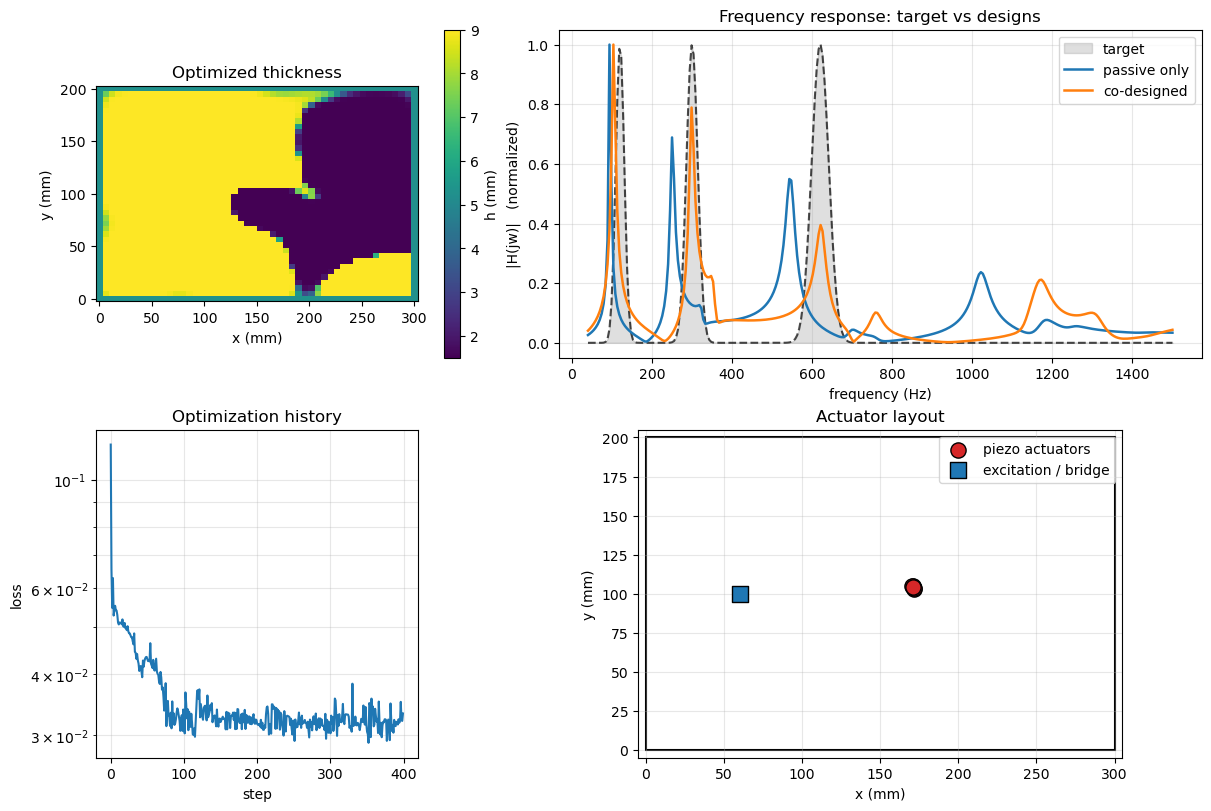

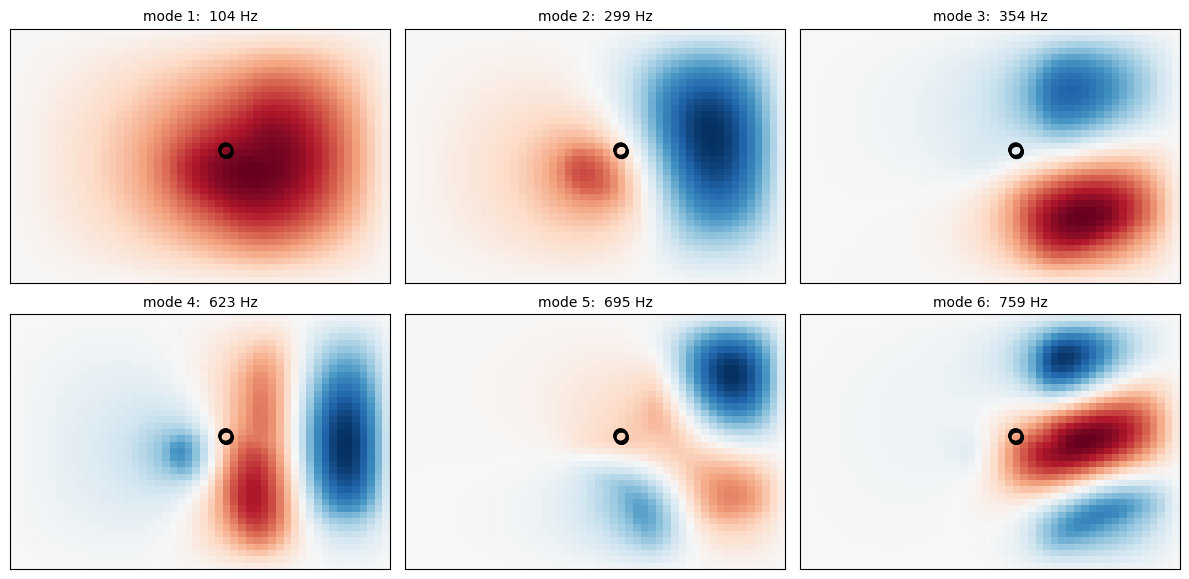

In [10]:
if MODE in ('lqr', 'both'):
    fig = plots.dashboard(params_lqr, history_lqr, freqs_lqr, target_lqr_run,
                          baseline_frf=H_passive_lqr, optimized_frf=H_lqr)
    fig.savefig('hero_lqr.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig = plots.plot_mode_shapes(c_lqr, positions=positions_lqr, n_show=6)
    fig.savefig('modes_lqr.png', dpi=160, bbox_inches='tight')
    plt.show()

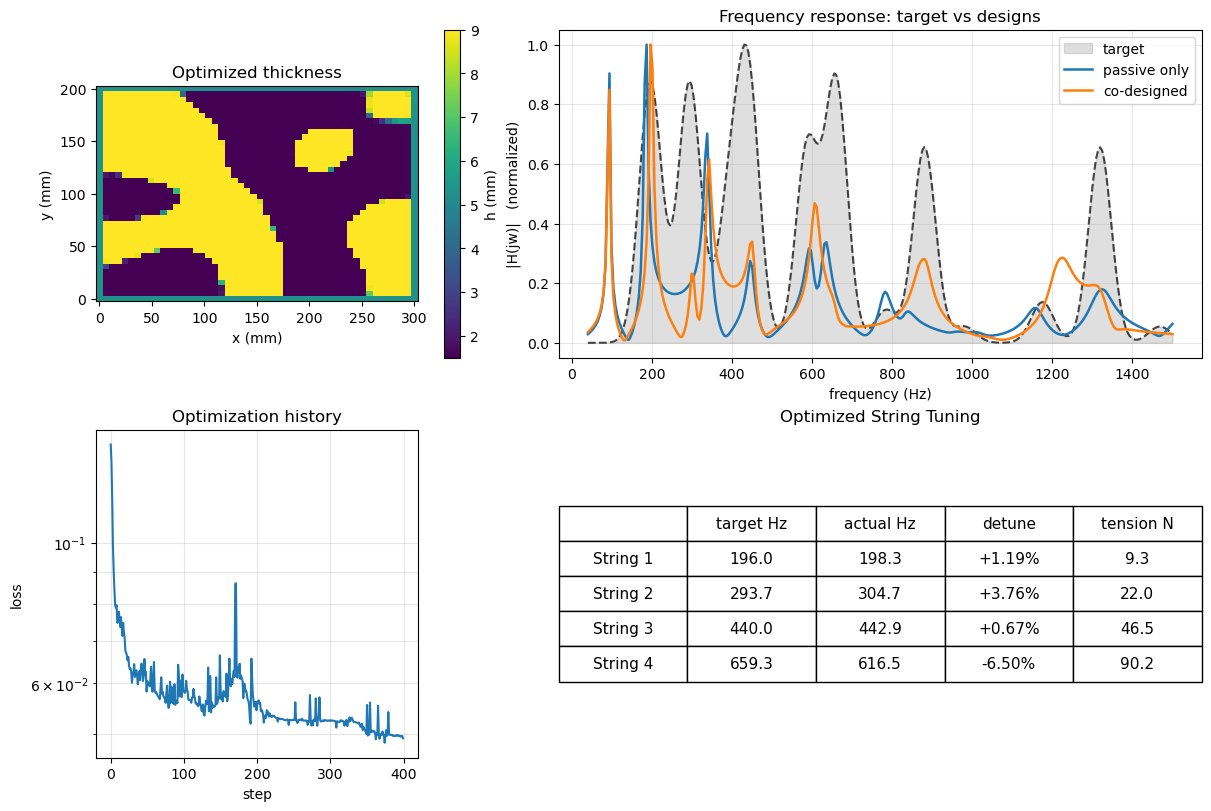

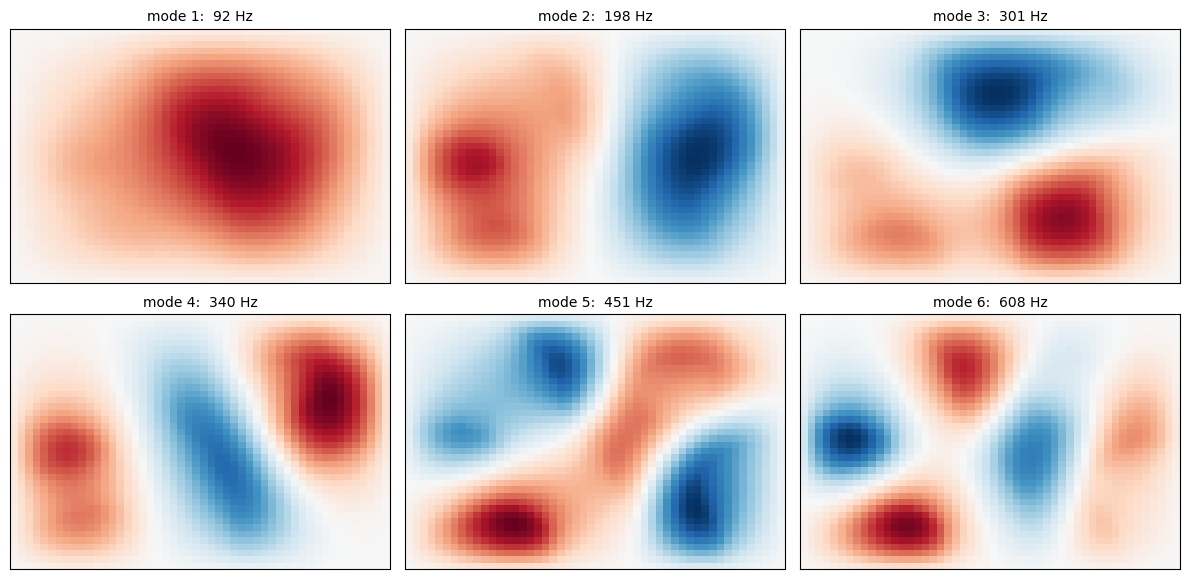

In [11]:
if MODE in ('strings', 'both'):
    table_headers = [('', 'target Hz', 'actual Hz', 'detune', 'tension N')]
    string_data = (table_headers, target_pitches, f0_str, tensions_N)
    params_str_plot = (c_str, log_tensions_str)

    fig_dash_str = plots.dashboard(
        params_str_plot, history_str, freqs_str_base, target_str_nominal,
        baseline_frf=H_passive_str,
        optimized_frf=H_str,
        string_table_data=string_data
    )
    fig_dash_str.savefig('hero_strings_dashboard.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig_modes_str = plots.plot_mode_shapes(c_str, n_show=6)
    fig_modes_str.savefig('modes_strings.png', dpi=160, bbox_inches='tight')
    plt.show()

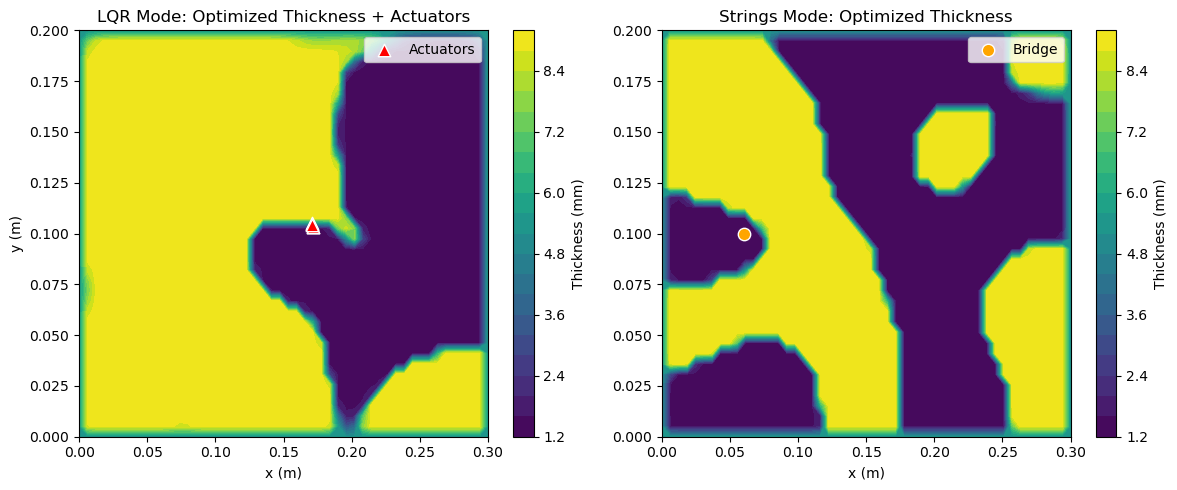

In [12]:
if MODE == 'both':
    # Create a side-by-side comparison figure using live memory variables
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    X, Y = np.asarray(core.X), np.asarray(core.Y)
    
    # --- Plot LQR Geometry ---
    h_lqr = np.asarray(core.thickness(c_lqr)) * 1e3
    im1 = ax1.contourf(X, Y, h_lqr, levels=20, cmap='viridis')
    px = positions_lqr[:, 0] * core.cfg.Lx
    py = positions_lqr[:, 1] * core.cfg.Ly
    ax1.scatter(px, py, c='red', edgecolors='white', s=80, marker='^', label='Actuators')
    ax1.set_title('LQR Mode: Optimized Thickness + Actuators')
    ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')
    ax1.legend(loc='upper right')
    fig.colorbar(im1, ax=ax1, label='Thickness (mm)')
    
    # --- Plot Strings Geometry ---
    h_str = np.asarray(core.thickness(c_str)) * 1e3
    im2 = ax2.contourf(X, Y, h_str, levels=20, cmap='viridis')
    bx, by = core.cfg.disturb_xy[0] * core.cfg.Lx, core.cfg.disturb_xy[1] * core.cfg.Ly
    ax2.scatter(bx, by, c='orange', edgecolors='white', s=80, marker='o', label='Bridge')
    ax2.set_title('Strings Mode: Optimized Thickness')
    ax2.set_xlabel('x (m)')
    ax2.legend(loc='upper right')
    fig.colorbar(im2, ax=ax2, label='Thickness (mm)')
    
    plt.tight_layout()
    fig.savefig('comparison_thickness_live.png', dpi=160)
    plt.show()

## 5. Save results

In [14]:
results = {
    'mode': MODE,
    'config': {
        'material': MATERIAL, 'scale': SCALE,
        'Lx': cfg.Lx, 'Ly': cfg.Ly, 'Nx': cfg.Nx, 'Ny': cfg.Ny,
        'M': cfg.M, 'n_modes': cfg.n_modes,
        'lqr_target_centers': LQR_TARGET_CENTERS,
        'lqr_target_widths': LQR_TARGET_WIDTHS,
    },
    'passive_lqr_best_loss': best_loss_passive_lqr if MODE in ('lqr', 'both') else None,
    'passive_str_best_loss': best_loss_passive_str if MODE in ('strings', 'both') else None,
}

if MODE in ('lqr', 'both'):
    results.update({
        'lqr_best_loss': float(best_loss_lqr),
        'lqr_improvement_pct': float(improvement_lqr),
        'lqr_history': [float(x) for x in history_lqr],
        'omega_hz_lqr': omega_hz_lqr,
        'actuator_positions': np.asarray(positions_lqr).tolist(),
        'log_q_final': float(log_q_lqr),
        'log_r_final': float(log_r_lqr),
    })

if MODE in ('strings', 'both'):
    results.update({
        'strings_best_loss': float(best_loss_str),
        'strings_history': [float(x) for x in history_str],
        'omega_hz_strings': omega_hz_str,
        'target_pitches_hz': list(target_pitches.tolist()),
        'actual_pitches_hz': f0_str.tolist(),
        'tensions_N': tensions_N.tolist(),
    })

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

save_args = {
    'freqs_lqr': np.asarray(freqs_lqr) if MODE in ('lqr', 'both') else np.array([]),
    'target_lqr': np.asarray(target_lqr) if MODE in ('lqr', 'both') else np.array([]),
}
if MODE in ('lqr', 'both'):
    save_args.update({
        'H_passive_lqr': H_passive_lqr,
        'history_passive_lqr': np.array(history_passive_lqr),
        'c_lqr': np.asarray(c_lqr),
        'positions_lqr': np.asarray(positions_lqr),
        'H_lqr': H_lqr,
        'history_lqr': np.array(history_lqr),
    })
if MODE in ('strings', 'both'):
    save_args.update({
        'H_passive_str': H_passive_str,
        'history_passive_str': np.array(history_passive_str),
        'c_str': np.asarray(c_str),
        'log_tensions_str': np.asarray(log_tensions_str),
        'H_str': H_str,
        'history_str': np.array(history_str),
        'target_str_nominal': target_str_nominal,
        'freqs_str': np.asarray(freqs_str_base),
    })
np.savez('best_params.npz', **save_args)
print('Saved results.json and best_params.npz')

Saved results.json and best_params.npz
